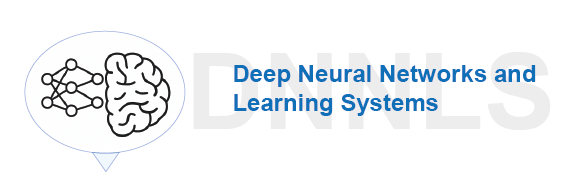

# Final assessment - Main Notebook
---

**Introduction:**

In this notebook you will find a baseline, functional architecture for your assessment task.

In [25]:
# @title Importing the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
import os



from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.transforms.functional as FT

from transformers import BertTokenizer
import gc

import textwrap


# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

In [48]:
# @title Setting up google drive to save checkpoints
"""
This cell handles the persistence of our model.
1. It mounts Google Drive to `/content/gdrive` so we can save files permanently.
2. `save_checkpoint_to_drive`: Saves the model state, optimizer state, and current epoch to a file in Drive.
3. `load_checkpoint_from_drive`: Restores the model and optimizer state from a file in Drive, allowing us to resume training.
"""

# This will prompt you to authorize Google Drive access
drive.mount('/content/gdrive')

def save_checkpoint_to_drive(model, optimizer, epoch, loss, filename="autoencoder_checkpoint.pth"):
    """
    Saves the checkpoint directly to a specified folder in your mounted Google Drive.
    """
    # 1. Define the full Google Drive path
    # 'DL_Checkpoints' is the folder you want to save to inside your Drive
    drive_folder = '/content/gdrive/MyDrive/dnn project'

    # Ensure the directory exists before attempting to save
    os.makedirs(drive_folder, exist_ok=True)

    # 2. Combine the folder and the filename
    full_path = os.path.join(drive_folder, filename)

    # 3. Create the checkpoint dictionary
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }

    # 4. Save the dictionary to the Google Drive path
    torch.save(checkpoint, full_path)
    print(f"Checkpoint saved to Google Drive: {full_path} at epoch {epoch}")


def load_checkpoint_from_drive(model, optimizer=None, filename="autoencoder_checkpoint.pth"):
    """
    Loads a checkpoint from your Google Drive folder into the model and optimizer (if provided).
    """
    # Define the same Google Drive folder path
    drive_folder = '/content/gdrive/MyDrive/dnn project'
    full_path = os.path.join(drive_folder, filename)

    # Check if the checkpoint file exists
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Checkpoint file not found: {full_path}")

    # Load the checkpoint
    checkpoint = torch.load(full_path, map_location=torch.device('cpu'))  # use cuda if available

    # Restore model state
    model.load_state_dict(checkpoint['model_state_dict'])

    # Restore optimizer state (if provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Extract metadata
    epoch = checkpoint.get('epoch', 0)
    loss = checkpoint.get('loss', None)

    print(f"Checkpoint loaded from: {full_path} (epoch {epoch})")

    return model, optimizer, epoch, loss

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [27]:
# @title Functions to show images and process data
"""
This cell provides essential data processing and visualization tools.
1. `parse_gdi_text`: Parses the raw "GDI" (Graph-Text-Interleaved) format from the dataset into a structured dictionary containing objects, actions, and locations.
2. `show_image`: A helper using matplotlib to display pytorch tensors as images, handling optional de-normalization.
"""

# This function just extracts the tags from the text, don't get distracted by it.
# I changed this function a bit to fix some bugs
def parse_gdi_text(text):
    """Parse GDI formatted text into structured data"""
    soup = BeautifulSoup(text, 'html.parser')
    images = []

    for gdi in soup.find_all('gdi'):
        # Debug: print what BeautifulSoup sees

        # Method 1: Try to get image attribute directly
        image_id = None
        if gdi.attrs:
            # Check for attributes like 'image1', 'image2', etc.
            for attr_name, attr_value in gdi.attrs.items():
                if 'image' in attr_name.lower():
                    image_id = attr_name.replace('image', '')
                    break

        # Method 2: Extract from the tag string using regex
        if not image_id:
            tag_str = str(gdi)
            match = re.search(r'<gdi\s+image(\d+)', tag_str)
            if match:
                image_id = match.group(1)

        # Method 3: Fallback - use sequential numbering
        if not image_id:
            image_id = str(len(images) + 1)

        content = gdi.get_text().strip()

        # Extract tagged elements using BeautifulSoup directly
        objects = [obj.get_text().strip() for obj in gdi.find_all('gdo')]
        actions = [act.get_text().strip() for act in gdi.find_all('gda')]
        locations = [loc.get_text().strip() for loc in gdi.find_all('gdl')]

        images.append({
            'image_id': image_id,
            'description': content,
            'objects': objects,
            'actions': actions,
            'locations': locations,
            'raw_text': str(gdi)
        })

    return images

# This is an utility function to show images.
# Why do we need to do all this?
def show_image(ax, image, de_normalize = False, img_mean = None, img_std = None):
  """
  De-normalize the image (if necessary) and show image
  """
  if de_normalize:
    new_mean = -img_mean/img_std
    new_std = 1/img_std

    image = transforms.Normalize(
        mean=new_mean,
        std=new_std
    )(image)
  ax.imshow(image.permute(1, 2, 0))

In [28]:
# @title CoT grounding helpers (added)
"""
This cell contains helper functions to parse the "Chain-of-Thought" (CoT) annotations provided in the dataset.
1. `parse_cot_grounding`: Extracts bounding boxes for characters and objects from the CoT markdown tables.
2. `crop_and_resize`: Crops an image region based on a bounding box and resizes it to a fixed size (60x125).
3. `pick_reid_pair`: Selects a pair of bounding boxes for the same entity across different frames to support Re-Identification (ReID) learning.
4. `extract_cot_text_for_frame`: Extracts the text reasoning corresponding to a specific frame.
"""

import random
import re
from typing import Dict, Any, List, Optional, Tuple

def _parse_markdown_table(block: str) -> List[Dict[str, str]]:
    lines = [l.rstrip() for l in block.splitlines()]
    table_lines = [l for l in lines if l.strip().startswith("|")]
    if len(table_lines) < 3:
        return []
    header_line = table_lines[0]
    data_lines = table_lines[2:]
    headers = [h.strip() for h in header_line.strip("|").split("|")]
    rows = []
    for line in data_lines:
        if not line.strip().startswith("|"):
            break
        cols = [c.strip() for c in line.strip("|").split("|")]
        if len(cols) != len(headers):
            continue
        rows.append(dict(zip(headers, cols)))
    return rows

def parse_cot_grounding(chain_of_thought: str) -> Dict[int, Dict[str, Any]]:
    """Parse StoryReasoning-style CoT markdown into per-frame bbox annotations."""
    frames: Dict[int, Dict[str, Any]] = {}
    img_pattern = re.compile(r"^##\s*Image\s+(\d+)", flags=re.MULTILINE)
    matches = list(img_pattern.finditer(chain_of_thought or ""))

    for i, m in enumerate(matches):
        img_idx = int(m.group(1)) - 1
        start = m.end()
        end = matches[i + 1].start() if (i + 1 < len(matches)) else len(chain_of_thought)
        section = (chain_of_thought or "")[start:end]

        frames[img_idx] = {"characters": [], "objects": []}

        char_match = re.search(r"###\s*Characters(.*?)(?=\n###|\n##|$)", section, flags=re.DOTALL)
        if char_match:
            for row in _parse_markdown_table(char_match.group(1)):
                cid = row.get("Character ID", "").strip()
                bbox_str = row.get("Bounding Box", "").strip()
                if cid and bbox_str:
                    try:
                        x1, y1, x2, y2 = [int(v) for v in bbox_str.split(",")]
                        frames[img_idx]["characters"].append({"id": cid, "bbox": [x1, y1, x2, y2]})
                    except Exception:
                        pass

        obj_match = re.search(r"###\s*Objects(.*?)(?=\n###|\n##|$)", section, flags=re.DOTALL)
        if obj_match:
            for row in _parse_markdown_table(obj_match.group(1)):
                oid = row.get("Object ID", "").strip()
                bbox_str = row.get("Bounding Box", "").strip()
                if oid and bbox_str:
                    try:
                        x1, y1, x2, y2 = [int(v) for v in bbox_str.split(",")]
                        frames[img_idx]["objects"].append({"id": oid, "bbox": [x1, y1, x2, y2]})
                    except Exception:
                        pass
    return frames

def _clamp_bbox(x1, y1, x2, y2, W, H):
    x1 = max(0, min(x1, W - 1))
    x2 = max(0, min(x2, W - 1))
    y1 = max(0, min(y1, H - 1))
    y2 = max(0, min(y2, H - 1))
    if x2 <= x1:
        x2 = min(W - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(H - 1, y1 + 1)
    return x1, y1, x2, y2

def crop_and_resize(pil_img, bbox, out_hw=(60, 125)):
    x1, y1, x2, y2 = bbox
    W, H = pil_img.size
    x1, y1, x2, y2 = _clamp_bbox(x1, y1, x2, y2, W, H)
    crop = pil_img.crop((x1, y1, x2, y2))
    crop = transforms.Resize(out_hw)(crop)
    crop = transforms.ToTensor()(crop)
    return crop

def pick_reid_pair(frames_cot: Dict[int, Dict[str, Any]]) -> Optional[Tuple[int, int, List[int], List[int], str]]:
    """Pick two detections of the same entity id across frames."""
    id_to_dets = {}
    for f_idx, content in frames_cot.items():
        for det in content.get("characters", []) + content.get("objects", []):
            ent_id = det.get("id")
            bbox = det.get("bbox")
            if ent_id and bbox:
                id_to_dets.setdefault(ent_id, []).append((f_idx, bbox))

    candidates = [ent_id for ent_id, dets in id_to_dets.items() if len(dets) >= 2]
    if not candidates:
        return None

    ent_id = random.choice(candidates)
    dets = id_to_dets[ent_id]
    (f1, b1), (f2, b2) = random.sample(dets, 2)
    return f1, f2, b1, b2, ent_id

def extract_cot_text_for_frame(chain_of_thought: str, frame_idx: int, max_chars: int = 600) -> str:
    """Option 4 helper: extract the 'Image N' section as plain text (best-effort)."""
    if not chain_of_thought:
        return ""
    img_pattern = re.compile(r"^##\s*Image\s+(\d+)", flags=re.MULTILINE)
    matches = list(img_pattern.finditer(chain_of_thought))
    target = None
    for i, m in enumerate(matches):
        if int(m.group(1)) - 1 == frame_idx:
            start = m.end()
            end = matches[i + 1].start() if (i + 1 < len(matches)) else len(chain_of_thought)
            target = chain_of_thought[start:end]
            break
    if target is None:
        return ""
    # Remove markdown tables (keep only non-table lines)
    lines = []
    for line in target.splitlines():
        if line.strip().startswith("|"):
            continue
        if set(line.strip()) <= set("-|:"):
            continue
        lines.append(line)
    text = " ".join([l.strip() for l in lines if l.strip()])
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]

Now we load dataset from HuggingFace:

In [29]:
# @title Loading the dataset
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

In a previous lab, we analyzed the statistics of the images and figure out that a size of 240x500 could be good enough to standarize, but we will use 60x125. Also, we will restrict ourselves to taking only 5 frames from all the sequences.


## 1.2 Three datasets


---



We will create three different dataset objects and the corresponding loaders for performing multiple tasks

In [30]:
# @title CoT improvements toggles (added)
"""
Configuration flags to control which Chain-of-Thought (CoT) mechanisms are used during training:
- `USE_FRAME_AWARE_GROUNDING`: Aligns ROI embeddings with the text embedding of the specific frame (vs global).
- `USE_CONTRASTIVE_ROI`: Enables InfoNCE loss to contrast positive ROI-text pairs against negatives.
- `USE_ENTITY_POOLING`: Enforces consistency of embeddings for the same entity within a batch.
- `USE_COT_TEXT`: Appends CoT reasoning text to the input frame description.
"""

# Turn these on/off to control the 4 optional improvements.
USE_FRAME_AWARE_GROUNDING = True      # Option 2: align ROI to matching frame text embedding (instead of always frame 0)
USE_CONTRASTIVE_ROI = True            # Option 1: InfoNCE-style contrastive grounding using batch negatives
USE_ENTITY_POOLING = True             # Option 3: entity-specific pooling/consistency across batch by entity_id
USE_COT_TEXT = True                   # Option 4: concatenate CoT text snippet to the frame descriptions

# Contrastive temperature (only used if USE_CONTRASTIVE_ROI=True)
CONTRASTIVE_TAU = 0.07

In [31]:
# @title Main dataset
"""
Defines the `SequencePredictionDataset` class, which is the core data provider for the main task.
1. `__getitem__`:
   - Loads 5 frames (4 context + 1 target).
   - Parses text descriptions and optionally appends CoT text.
   - Extracts bounding box crops (ROIs) for grounding tasks if CoT data is available.
   - Returns a tuple containing: sequence images, descriptions, target image, target text, ROI crops, and validity flags.
"""

class SequencePredictionDataset(Dataset):
    def __init__(self, original_dataset, tokenizer, K: int = 4, max_len: int = 120, image_hw=(60, 125)):
        super(SequencePredictionDataset, self).__init__()
        self.dataset = original_dataset
        self.tokenizer = tokenizer
        self.K = K
        self.max_len = max_len
        self.image_hw = image_hw

        # Potential experiments: Try other transforms!
        self.transform = transforms.Compose([
          transforms.Resize(image_hw),  # Reasonable size based on our previous analysis
          transforms.ToTensor(),        # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      """
      Selects a 5 frame sequence from the dataset. Sets 4 for training and the last one
      as a target.

      Returns:
        frames:        [K, C, H, W]
        descriptions:  [K, T]
        image_target:  [C, H, W]
        target_ids:    [1, T]
        roi1, roi2:    [C, H, W] (cropped from CoT bboxes, if available)
        roi_valid:     0/1
        roi_frame:     frame index for roi1 (0..K-1) if available else -1
        ent_id:        string id for the ROI entity (empty if none)
      """
      frames = self.dataset[idx]["images"]
      image_attributes = parse_gdi_text(self.dataset[idx]["story"])

      # CoT grounding annotations (may be missing / unparseable)
      cot = self.dataset[idx].get("chain_of_thought", "")
      cot_frames = parse_cot_grounding(cot)

      frame_tensors = []
      description_list = []

      for frame_idx in range(self.K):
        image = FT.equalize(frames[frame_idx])
        input_frame = self.transform(image)
        frame_tensors.append(input_frame)

        description = image_attributes[frame_idx]["description"]

        # Option 4: include CoT text snippet for this frame (best-effort)
        if USE_COT_TEXT:
          cot_txt = extract_cot_text_for_frame(cot, frame_idx)
          if cot_txt:
            description = description + " [COT] " + cot_txt

        input_ids = self.tokenizer(
            description,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_len
        ).input_ids.squeeze(0)

        description_list.append(input_ids)

      image_target = FT.equalize(frames[self.K])
      image_target = self.transform(image_target)

      target_desc = image_attributes[self.K]["description"]
      target_ids = self.tokenizer(
          target_desc,
          return_tensors="pt",
          padding="max_length",
          truncation=True,
          max_length=self.max_len
      ).input_ids  # [1, T]

      # ---- CoT ROI pair (Options 1-3 need these) ----
      roi_valid = torch.tensor(0, dtype=torch.long)
      roi1 = torch.zeros((3, self.image_hw[0], self.image_hw[1]))
      roi2 = torch.zeros((3, self.image_hw[0], self.image_hw[1]))
      roi_frame = torch.tensor(-1, dtype=torch.long)
      ent_id = ""

      pair = pick_reid_pair(cot_frames)
      if pair is not None:
        f1, f2, b1, b2, ent_id = pair
        # We only use ROIs that fall within the input window (0..K-1)
        if (0 <= f1 < self.K) and (0 <= f2 < self.K):
          try:
            roi1 = crop_and_resize(frames[f1], b1, out_hw=self.image_hw)
            roi2 = crop_and_resize(frames[f2], b2, out_hw=self.image_hw)
            roi_valid = torch.tensor(1, dtype=torch.long)
            roi_frame = torch.tensor(int(f1), dtype=torch.long)
          except Exception:
            pass

      sequence_tensor = torch.stack(frame_tensors)          # [K, C, H, W]
      description_tensor = torch.stack(description_list)    # [K, T]

      return (
          sequence_tensor,
          description_tensor,
          image_target,
          target_ids,
          roi1, roi2, roi_valid, roi_frame, ent_id
      )

We will use text autoencoding (reconstructing the same text) to develop representations of the text (I provide some existing weights for this, but you can train your own)

In [32]:
# @title Text task dataset (text autoencoding)
"""
Defines `TextTaskDataset` for pre-training or fine-tuning the text encoder separately.
It simply pulls a random text description from a story to perform text-to-text autoencoding.
"""

class TextTaskDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      num_frames = self.dataset[idx]["frame_count"]
      self.image_attributes = parse_gdi_text(self.dataset[idx]["story"])

      # Pick
      frame_idx = np.random.randint(0, 5)
      description = self.image_attributes[frame_idx]["description"]

      return description  # Returning the whole description

And also a dataset for a potential image autoencoder task if you want to develop some visual features before training the whose archicture.

In [33]:
# @title Dataset for image autoencoder task
"""
Defines `AutoEncoderTaskDataset` for pre-training the visual autoencoder.
It retrieves a single random frame from the dataset to learn image reconstruction (Image -> Latent -> Image).
"""

class AutoEncoderTaskDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([
          transforms.Resize((240, 500)),# Reasonable size based on our previous analysis
          transforms.ToTensor(), # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      num_frames = self.dataset[idx]["frame_count"]
      frames = self.dataset[idx]["images"]

      # Pick a frame at random
      frame_idx = torch.randint(0, 5, (1,)).item()
      input_frame = self.transform(frames[frame_idx]) # Input to the autoencoder

      return input_frame, # Returning the image

## 1.3 Creating and testing our dataset objects and loaders


---



In [34]:
# @title For the Sequence prediction task
"""
This cell sets up the data pipeline for the main sequence prediction task.
1. Initializes the BERT tokenizer.
2. Creates `SequencePredictionDataset` instances for training and testing.
3. Splits the training data into `train_subset` and `val_subset`.
4. Creates `DataLoader` objects (`train_dataloader`, `val_dataloader`, `test_dataloader`) to batch and shuffle the data.
"""

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=4, shuffle=False)

In [35]:
# @title For the text task
"""
Sets up the data pipeline for the auxiliary text autoencoding task.
Creates the `TextTaskDataset` and its corresponding `DataLoader`.
"""

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
text_dataset = TextTaskDataset(train_dataset)
text_dataloader = DataLoader(text_dataset, batch_size=4, shuffle=True)

In [36]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderTaskDataset` and its `DataLoader`.
"""

autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=4, shuffle=True)

Description:  torch.Size([4, 120])
torch.Size([8, 4, 3, 60, 125])
torch.Size([8, 4, 120])


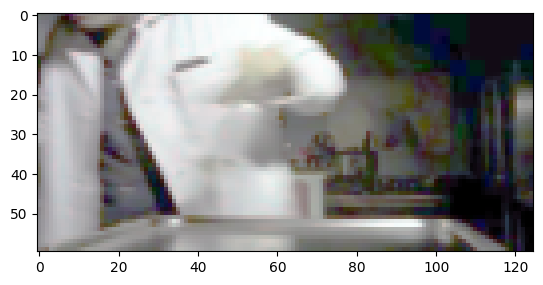

In [37]:
"""
A sanity check cell to verify the data pipeline.
It grabs a single batch from the training dataset and prints the shapes of the returned tensors (images, descriptions, etc.) to ensure everything is loaded correctly.
"""

frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = sp_train_dataset[np.random.randint(0,400)]

print("Description: ", descriptions.shape)
figure, ax = plt.subplots(1,1)
show_image(ax, image_target)

# Do some tests on the batches (try with batch size small)
frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(train_dataloader))
print(frames.shape)
print(descriptions.shape)

I will leave the test of the other datasets to you.

# **Chapter 2: Models**


---



We provide a simple text encoder based on a recurrent neural network (LSTM). Feel free to provide your own text encoder.

## 2.1 The NLP models

In [38]:
# @title The text autoencoder (Seq2Seq)
"""
Defines the neural network modules for processing text:
1. `EncoderLSTM`: Encodes text tokens into a hidden state vector using an LSTM.
2. `DecoderLSTM`: Decodes a hidden state back into text tokens using an LSTM.
3. `Seq2SeqLSTM`: Combines the encoder and decoder into a full autoencoder architecture.
"""

class EncoderLSTM(nn.Module):
    """
      Encodes a sequence of tokens into a latent space representation.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)

    def forward(self, input_seq):
        embedded = self.embedding(input_seq)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class DecoderLSTM(nn.Module):
    """
      Decodes a latent space representation into a sequence of tokens.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.out = nn.Linear(hidden_dim, vocab_size) # Should be hidden_dim

    def forward(self, input_seq, hidden, cell):
        embedded = self.embedding(input_seq)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.out(output)
        return prediction, hidden, cell

# We create the basic text autoencoder (a special case of a sequence to sequence model)
class Seq2SeqLSTM(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, input_seq, target_seq):
        # input_seq and target_seq are both your 'input_ids'
        # 1. Encode the input sequence
        _enc_out, hidden, cell = self.encoder(input_seq)

        # 2. Create the "shifted" decoder input for teacher forcing.
        # We want to predict target_seq[:, 1:]
        # So, we feed in target_seq[:, :-1]
        # (i.e., feed "[SOS], hello, world" to predict "hello, world, [EOS]")
        decoder_input = target_seq[:, :-1]

        # 3. Run the decoder *once* on the entire sequence.
        # It takes the encoder's final state (hidden, cell)
        # and the full "teacher" sequence (decoder_input).
        predictions, _hidden, _cell = self.decoder(decoder_input, hidden, cell)

        # predictions shape will be (batch_size, seq_len-1, vocab_size)
        return predictions

In [39]:
# @title Utility functions for NLP tasks
"""
1. `generate`: An inference function for the text decoder.
   - It performs autoregressive generation: predicting one token at a time and feeding it back as input for the next step.
   - Uses temperature scaling for sampling diversity.
"""

def generate(model, hidden, cell, max_len, sos_token_id, eos_token_id):
      """
        This function generates a sequence of tokens using the provided decoder.
      """
      # Ensure the model is in evaluation mode
      model.eval()

      # 2. SETUP DECODER INPUT
      # Start with the SOS token, shape (1, 1)
      dec_input = torch.tensor([[sos_token_id]], dtype=torch.long, device=device)
      # hidden = torch.zeros(1, 1, hidden_dim, device=device)
      # cell = torch.zeros(1, 1, hidden_dim, device=device)

      generated_tokens = []

      # 3. AUTOREGRESSIVE LOOP
      for _ in range(max_len):
          with torch.no_grad():
              # Run the decoder one step at a time
              # dec_input is (1, 1) here—it's just the last predicted token
              prediction, hidden, cell = model(dec_input, hidden, cell)

          logits = prediction.squeeze(1) # Shape (1, vocab_size)
          temperature = 0.9 # <--- Try a value between 0.5 and 1.0

          # 1. Divide logits by temperature
          # 2. Apply softmax to get probabilities
          # 3. Use multinomial to sample one token based on the probabilities
          probabilities = torch.softmax(logits / temperature, dim=-1)
          next_token = torch.multinomial(probabilities, num_samples=1)

          token_id = next_token.squeeze().item()

          # Check for the End-of-Sequence token
          if token_id == eos_token_id:
              break

          if token_id == 0 or token_id == sos_token_id:
              continue

            # Append the predicted token
          generated_tokens.append(token_id)

          # The predicted token becomes the input for the next iteration
          dec_input = next_token

      # Return the list of generated token IDs
      return generated_tokens

In [40]:
# @title Do some tests
"""
Manually testing the text generation capabilities of the model.
"""

# desc = text_dataset[np.random.randint(0, 100)]
# print(f"Input: {desc}")
# input_ids = tokenizer(desc, return_tensors="pt",  padding=True, truncation=True).input_ids
# input_ids = input_ids.to(device)
# generated_tokens = generate(model, hidden, cell, max_len=100, sos_token_id=tokenizer.cls_token_id, eos_token_id=tokenizer.sep_token_id)
# print("Output: ", tokenizer.decode(generated_tokens))

'\nManually testing the text generation capabilities of the model.\n'

## 2.2 The Vision models

In [41]:
# @title The visual autoencoder
"""
Defines the computer vision modules:
1. `Backbone`: A CNN that processes input images into feature maps.
2. `VisualEncoder`: Uses two backbones to separate 'content' and 'context' features, projecting them to a latent space.
3. `VisualDecoder`: Reconstructs images from the latent representation using Transposed Convolutions.
4. `VisualAutoencoder`: The container class for the encoder and decoder.
"""

class Backbone(nn.Module):
    """
      Main convolutional blocks for our CNN
    """
    def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
        super(Backbone, self).__init__()
        # Encoder convolutional layers
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 16, 7, stride=2, padding=3),
            nn.GroupNorm(8, 16),
            nn.LeakyReLU(0.1),

            nn.Conv2d(16, 32, 5, stride=2, padding=2),
            nn.GroupNorm(8, 32),
            nn.LeakyReLU(0.1),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(0.1),
        )

        # Calculate flattened dimension for linear layer
        self.flatten_dim = 64 * output_w * output_h
        # Latent space layers
        self.fc1 = nn.Sequential(nn.Linear(self.flatten_dim, latent_dim), nn.ReLU())


    def forward(self, x):
        x = self.encoder_conv(x)
        x = x.view(-1, self.flatten_dim)  # flatten for linear layer
        z = self.fc1(x)
        return z

class VisualEncoder(nn.Module):
    """
      Encodes an image into a latent space representation. Note the two pathways
      to try to disentangle the mean pattern from the image
    """
    def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
        super(VisualEncoder, self).__init__()

        self.context_backbone = Backbone(latent_dim, output_w, output_h)
        self.content_backbone = Backbone(latent_dim, output_w, output_h)

        self.projection = nn.Linear(2*latent_dim, latent_dim)
    def forward(self, x):
        z_context = self.context_backbone(x)
        z_content = self.content_backbone(x)
        z = torch.cat((z_content, z_context), dim=1)
        z = self.projection(z)
        return z

class VisualDecoder(nn.Module):
    """
      Decodes a latent representation into a content image and a context image
    """
    def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
        super(VisualDecoder, self).__init__()
        self.imh = 60
        self.imw = 125
        self.flatten_dim = 64 * output_w * output_h
        self.output_w = output_w
        self.output_h = output_h

        self.fc1 = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder_conv = nn.Sequential(
          nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1,1)),
          nn.GroupNorm(8, 32),
          nn.LeakyReLU(0.1),

          nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
          nn.GroupNorm(8, 16),
          nn.LeakyReLU(0.1),

          nn.ConvTranspose2d(16, 3, kernel_size=7, stride=2, padding=3, output_padding=(1, 1)),
          nn.Sigmoid() # Use nn.Tanh() if your data is normalized to [-1, 1]
      )

    def forward(self, z):
      x = self.fc1(z)

      x_content = self.decode_image(x)
      x_context = self.decode_image(x)

      return x_content, x_context

    def decode_image(self, x):
      x = x.view(-1, 64, self.output_w, self.output_h)      # reshape to conv feature map
      x = self.decoder_conv(x)
      x = x[:, :, :self.imh, :self.imw]          # crop to original size if needed
      return x

class VisualAutoencoder( nn.Module):
    def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
        super(VisualAutoencoder, self).__init__()
        self.encoder = VisualEncoder(latent_dim, output_w, output_h)
        self.decoder = VisualDecoder(latent_dim, output_w, output_h)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## 2.3 The main architecture


In [42]:
# @title A simple attention architecture
"""
Defines an `Attention` module.
It computes attention weights over a sequence of RNN outputs to create a context vector, helping the model focus on relevant parts of the input sequence.
"""

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # This "attention" layer learns a query vector
        self.attn = nn.Linear(hidden_dim, 1)
        self.softmax = nn.Softmax(dim=1) # Over the sequence length

    def forward(self, rnn_outputs):
        # rnn_outputs shape: [batch, seq_len, hidden_dim]

        # Pass through linear layer to get "energy" scores
        energy = self.attn(rnn_outputs).squeeze(2) # Shape: [batch, seq_len]

        # Get attention weights
        attn_weights = self.softmax(energy) # Shape: [batch, seq_len]

        # Apply weights
        # attn_weights.unsqueeze(1) -> [batch, 1, seq_len]
        # bmm with rnn_outputs -> [batch, 1, hidden_dim]
        context = torch.bmm(attn_weights.unsqueeze(1), rnn_outputs)

        # Squeeze to get final context vector
        return context.squeeze(1) # Shape: [batch, hidden_dim]

In [43]:
# @title The main sequence predictor model
"""
This is the core architecture `SequencePredictor`.
1. **Encoders**: Uses the `image_encoder` and `text_encoder` to process the sequence of 4 input frames and descriptions.
2. **Temporal Fusion**: A GRU processes the sequence of fused (image+text) embeddings to capture temporal dynamics.
3. **Attention**: Applies attention over the sequence to summarize context.
4. **Decoders**: Predicts the *next* (5th) frame's image and text using `image_decoder` and `text_decoder`.
"""

class SequencePredictor(nn.Module):
    def __init__(self, visual_autoencoder, text_autoencoder, latent_dim,
                 gru_hidden_dim):
        super(SequencePredictor, self).__init__()

        # --- 1. Static Encoders ---
        # (These process one pair at a time)
        self.image_encoder = visual_autoencoder.encoder
        self.text_encoder = text_autoencoder.encoder

        # --- 2. Temporal Encoder ---
        # (This processes the sequence of pairs)
        fusion_dim = latent_dim * 2 # z_visual + z_text
        self.temporal_rnn = nn.GRU(fusion_dim, latent_dim, batch_first=True)

        # --- 3. Attention ---
        self.attention = Attention(gru_hidden_dim)

        # --- 4. Final Projection ---
        # cat(h, context) -> gru_hidden_dim * 2
        self.projection = nn.Sequential(
            nn.Linear(gru_hidden_dim * 2, latent_dim),
            nn.ReLU()
        )

        # --- 5. Decoders ---
        # (These predict the *next* item)
        self.image_decoder = visual_autoencoder.decoder
        self.text_decoder = text_autoencoder.decoder

        self.fused_to_h0 = nn.Linear(latent_dim, 16)
        self.fused_to_c0 = nn.Linear(latent_dim, 16)

    def forward(self, image_seq, text_seq, target_seq):
        # image_seq shape: [batch, seq_len, C, H, W]
        # text_seq shape:  [batch, seq_len, text_len]
        # target_text_for_teacher_forcing: [batch, text_len] (This is the last text)

        batch_size, seq_len, C, H, W = image_seq.shape

        # --- 1 & 2: Run Static Encoders over the sequence ---
        # We can't pass a 5D/4D tensor to the encoders.
        # We "flatten" the batch and sequence dimensions.

        # Reshape for image_encoder
        img_flat = image_seq.view(batch_size * seq_len, C, H, W)
        # Reshape for text_encoder
        txt_flat = text_seq.view(batch_size * seq_len, -1) # -1 infers text_len

        # Run encoders
        z_v_flat = self.image_encoder(img_flat) # Shape: [b*s, latent]
        _, hidden, cell = self.text_encoder(txt_flat) # Shape: [b*s, latent]

        # Keep per-frame latents for optional grounding losses
        z_v_seq = z_v_flat.view(batch_size, seq_len, -1)                 # [b, s, latent]
        z_t_seq = hidden.squeeze(0).view(batch_size, seq_len, -1)        # [b, s, latent]

        # Combine
        z_fusion_flat = torch.cat((z_v_flat, hidden.squeeze(0)), dim=1) # Shape: [b*s, fusion_dim]

        # "Un-flatten" back into a sequence
        z_fusion_seq = z_fusion_flat.view(batch_size, seq_len, -1) # Shape: [b, s, fusion_dim]

        # --- 3. Run Temporal Encoder ---
        # zseq shape: [b, s, gru_hidden]
        # h    shape: [1, b, gru_hidden]
        zseq, h = self.temporal_rnn(z_fusion_seq)
        h = h.squeeze(0) # Shape: [b, gru_hidden]

        # --- 4. Attention ---
        context = self.attention(zseq) # Shape: [b, gru_hidden]

        # --- 5. Final Prediction Vector (z) ---
        z = self.projection(torch.cat((h, context), dim=1)) # Shape: [b, joint_latent_dim]

        # --- 6. Decode (Predict pk) ---
        pred_image_content, pred_image_context = self.image_decoder(z)

        h0 = self.fused_to_h0(z).unsqueeze(0)
        c0 = self.fused_to_c0(z).unsqueeze(0)

        decoder_input = target_seq[:, :,:-1].squeeze(1)

        # 3. Run the decoder *once* on the entire sequence.
        # It takes the encoder's final state (hidden, cell)
        # and the full "teacher" sequence (decoder_input).
        predicted_text_logits_k, _hidden, _cell = self.text_decoder(decoder_input, h0, c0)

        return pred_image_content, pred_image_context, predicted_text_logits_k, h0, c0, z_v_seq, z_t_seq

# **Chapter 3: Training routines**


---




In [44]:
# @title Training utility functions: To initialize and to visualize the progress
"""
1. `init_weights`: Initializes neural network weights using Kaiming Normal initialization.
2. `validation`: A visualization routine. It runs the model on a validation batch and plots:
   - The 4 input frames and their descriptions.
   - The target (Ground Truth) frame and description.
   - The model's predicted frame and generated text description.
"""

def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
        nn.init.constant_(m.bias, 0)


# Plots four images and their reconstructions
def validation( model, data_loader ):
  model.eval()
  with torch.no_grad():
    # Unpack 9 values (dataset was updated to return CoT info)
    frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(data_loader))

    descriptions = descriptions.to(device)
    frames = frames.to(device)
    image_target = image_target.to(device)
    text_target = text_target.to(device)

    # Unpack 7 values (model now returns extra latents for grounding)
    predicted_image_k, context_image, _, hidden, cell, _, _ = model(frames, descriptions, text_target)

    figure, ax = plt.subplots(2, 6, figsize=(20, 5), gridspec_kw={'height_ratios': [2, 1.5]})

    for i in range(4):
      im = frames[0, i, :, :, :].cpu()
      show_image(ax[0,i], im )
      ax[0,i].set_aspect('auto')
      ax[0,i].axis('off')
      wrapped_text = textwrap.fill(tokenizer.decode(descriptions[0, i, :], skip_special_tokens=True), width=40)

      ax[1,i].text(
            0.5, 0.99,
            wrapped_text,
            ha='center',
            va='top',
            fontsize=10,
            wrap=True
        )

      ax[1,i].axis('off') # Hide axes for the text subplot

    show_image(ax[0,4], image_target[0].cpu())
    ax[0,4].set_title('Target')
    ax[0,4].set_aspect('auto')
    ax[0,4].axis('off')
    text_target = text_target.squeeze(1)

    wrapped_text = textwrap.fill(tokenizer.decode(text_target[0], skip_special_tokens=True), width=40)
    ax[1,4].text(
            0.5, 0.99,
            wrapped_text,
            ha='center',
            va='top',
            fontsize=10,
            wrap=False)
    ax[1,4].axis('off')
    output = context_image[0, :, :, :].cpu()
    show_image(ax[0,5], output)
    ax[0,5].set_title('Predicted')
    ax[0,5].set_aspect('auto')
    ax[0,5].axis('off')

    generated_tokens = generate(model.text_decoder,
                                hidden[:,0, :].unsqueeze(1),
                                cell[:, 0, :].unsqueeze(1),
                                max_len=150,
                                sos_token_id=tokenizer.cls_token_id,
                                eos_token_id=tokenizer.sep_token_id)

    wrapped_text = textwrap.fill(tokenizer.decode(generated_tokens), width=40)

    ax[1,5].text(
            0.5, 0.99,
            wrapped_text,
            ha='center',
            va='top',
            fontsize=10,
            wrap=False )
    ax[1,5].axis('off')
    plt.tight_layout()
    plt.show()

## 3.1 Initialization and setup

In [45]:
# @title Variables and initial setup
"""
Global setup:
- Sets the computation device (CUDA/CPU).
- Defines hyperparameters: `N_EPOCHS`, `emb_dim`, `latent_dim`, etc.
"""

torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_EPOCHS = 5
emb_dim = 16
latent_dim = 16
num_layers = 1
dropout = True

In [49]:
# @title Initializing the NLP models
"""
1. Instantiates the `EncoderLSTM`, `DecoderLSTM`, and `Seq2SeqLSTM`.
2. Loads pre-trained weights from Google Drive (`text_autoencoder.pth`).
3. Freezes the text autoencoder parameters to keep them fixed during the main training phase.
"""

encoder = EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
decoder = DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
text_autoencoder = Seq2SeqLSTM(encoder, decoder).to(device)
text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder (2).pth')

total_params = sum(p.numel() for p in text_autoencoder.parameters())
print(f"Total parameters (Not trainable): {total_params}")
# Deactivating training from this model for efficiency (although not ideal)
for param in text_autoencoder.parameters():
        param.requires_grad = False

Checkpoint loaded from: /content/gdrive/MyDrive/dnn project/text_autoencoder (2).pth (epoch 15)
Total parameters (Not trainable): 1499930


In [50]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""

visual_autoencoder = VisualAutoencoder(latent_dim=16)
visual_autoencoder.apply(init_weights)

total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
print(f"Total trainable parameters in visual autoencoder: {total_params}")

Total trainable parameters in visual autoencoder: 503539


In [51]:
# @title Initialize the main architecture
"""
Instantiates the full `SequencePredictor` model, wiring together the visual encoder, text encoder, and the sequence modeling components.
Prints the total number of parameters.
"""

# We put all the sizes the same, not ideal as well
sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, latent_dim, latent_dim)
sequence_predictor.to(device)

# # Print number of trainable parameters
total_params = sum(p.numel() for p in sequence_predictor.parameters() if p.requires_grad)
print(f"Total trainable parameters in the whole model: {total_params}")

# Print model size
total_params = sum(p.numel() for p in sequence_predictor.parameters())
print(f"Total parameters: {total_params}")

Total trainable parameters in the whole model: 507028
Total parameters: 2006958


## 3.2 Training loops

In [52]:
# @title Training tools
"""
Sets up the optimization process:
1. `criterion_images`: L1 Loss for image reconstruction.
2. `criterion_ctx`: MSE Loss for context guidance (mean color).
3. `criterion_text`: CrossEntropy Loss for text generation.
4. `optimizer`: Adam optimizer for updating model weights.
"""

criterion_images = nn.L1Loss()
criterion_ctx = nn.MSELoss()
criterion_text = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
optimizer = torch.optim.Adam(sequence_predictor.parameters(), lr=0.001)

In [53]:
# @title Training loop for the sequence predictor
"""
The main training loop:
1. Iterates over epochs and batches.
2. Performs the forward pass to get predictions and latent representations.
3. Computes the **Base Losses**: Image L1, Context MSE, Text CrossEntropy.
4. Computes **CoT Grounding Losses** (if data is valid):
   - `loss_reid`: Visual consistency for re-identified entities.
   - `loss_ground_mse`: Embedding alignment between ROI and text.
   - `loss_contrast`: Contrastive loss for ROI-Text alignment.
   - `loss_entity_pool`: Consistency within the batch for the same entity.
5. Backpropagates total loss and updates weights.
6. Runs the validation visualization at the end of each epoch.
"""

# Instantiate the model, define loss and optimizer

# --- CoT-loss weights (added) ---
LAMBDA_REID = 0.10            # pulls same-entity ROIs together (student idea)
LAMBDA_GROUND_MSE = 0.10      # Option 2: frame-aware ROI↔text MSE grounding
LAMBDA_CONTRAST = 0.10        # Option 1: contrastive ROI↔text grounding (InfoNCE)
LAMBDA_ENTITY_POOL = 0.05     # Option 3: within-batch entity pooling loss

sequence_predictor.train()
losses = []

for epoch in range(N_EPOCHS):

    running_loss = 0.0
    for (frames, descriptions, image_target, text_target,
         roi1, roi2, roi_valid, roi_frame, ent_id) in train_dataloader:

      # Send images and tokens to the GPU
      descriptions = descriptions.to(device)
      frames = frames.to(device)
      image_target = image_target.to(device)
      text_target = text_target.to(device)

      roi1 = roi1.to(device)
      roi2 = roi2.to(device)
      roi_valid = roi_valid.to(device)
      roi_frame = roi_frame.to(device)

      optimizer.zero_grad()

      # Predictions from our model (+ per-frame latents for CoT grounding)
      pred_image_content, pred_image_context, predicted_text_logits_k, _, _, z_v_seq, z_t_seq = sequence_predictor(
          frames, descriptions, text_target
      )

      # -------------------------
      # Base losses (unchanged)
      # -------------------------
      loss_im = criterion_images(pred_image_content, image_target)

      mu_global = frames.mean(dim=[0, 1])
      mu_global = mu_global.unsqueeze(0).expand_as(pred_image_context)
      loss_context = criterion_ctx(pred_image_context, mu_global)

      prediction_flat = predicted_text_logits_k.reshape(-1, tokenizer.vocab_size)
      target_labels = text_target.squeeze(1)[:, 1:]  # shift for teacher forcing
      target_flat = target_labels.reshape(-1)
      loss_text = criterion_text(prediction_flat, target_flat)

      # -------------------------
      # CoT-based grounding losses (added)
      # -------------------------
      loss_reid = torch.tensor(0.0, device=device)
      loss_ground_mse = torch.tensor(0.0, device=device)
      loss_contrast = torch.tensor(0.0, device=device)
      loss_entity_pool = torch.tensor(0.0, device=device)

      if roi_valid.any():
        mask = roi_valid.bool()
        if mask.sum() > 0:
          z_r1 = sequence_predictor.image_encoder(roi1[mask])  # [M,D]
          z_r2 = sequence_predictor.image_encoder(roi2[mask])  # [M,D]

          # Simplest grounding: same entity across frames -> close in embedding
          loss_reid = F.mse_loss(z_r1, z_r2)

          # Option 2: frame-aware grounding MSE (ROI aligned to the description embedding of its frame)
          if USE_FRAME_AWARE_GROUNDING:
            f = roi_frame[mask].clamp(min=0, max=z_t_seq.size(1)-1)  # [M]
            z_t_match = z_t_seq[mask].gather(
                1, f.view(-1, 1, 1).expand(-1, 1, z_t_seq.size(-1))
            ).squeeze(1)  # [M,D]
            loss_ground_mse = F.mse_loss(z_r1, z_t_match)

          # Option 1: contrastive ROI↔text grounding (InfoNCE with batch negatives)
          if USE_CONTRASTIVE_ROI and USE_FRAME_AWARE_GROUNDING:
            # Normalize for cosine similarity
            z_img = F.normalize(z_r1, dim=-1)
            z_txt = F.normalize(z_t_match, dim=-1)
            logits = (z_img @ z_txt.t()) / CONTRASTIVE_TAU  # [M,M]
            labels = torch.arange(logits.size(0), device=device)
            loss_contrast = F.cross_entropy(logits, labels)

          # Option 3: entity-specific pooling/consistency across batch
          if USE_ENTITY_POOLING:
            # ent_id comes from the DataLoader as a list of strings
            ent_list = [ent_id[i] for i, m in enumerate(mask.detach().cpu().tolist()) if m]
            # group embeddings by entity id and pull to group mean (within-batch)
            uniq = {}
            for i_e, eid in enumerate(ent_list):
              if not eid:
                continue
              uniq.setdefault(eid, []).append(i_e)

            if len(uniq) > 0:
              pool_losses = []
              for eid, idxs in uniq.items():
                if len(idxs) < 2:
                  continue
                group = z_r1[idxs]  # [G,D]
                mean = group.mean(dim=0, keepdim=True)
                pool_losses.append(F.mse_loss(group, mean.expand_as(group)))
              if len(pool_losses) > 0:
                loss_entity_pool = torch.stack(pool_losses).mean()

      # Total loss (base + optional improvements)
      loss = loss_im + loss_context + loss_text
      loss = loss + LAMBDA_REID * loss_reid
      loss = loss + LAMBDA_GROUND_MSE * loss_ground_mse
      loss = loss + LAMBDA_CONTRAST * loss_contrast
      loss = loss + LAMBDA_ENTITY_POOL * loss_entity_pool

      loss.backward()
      optimizer.step()

      running_loss += loss.item()

    epoch_loss = running_loss / len(train_dataloader)
    losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{N_EPOCHS}] Loss: {epoch_loss:.4f}  "
        f"(im={loss_im.item():.3f}, ctx={loss_context.item():.3f}, txt={loss_text.item():.3f}, "
        f"reid={float(loss_reid):.3f}, g_mse={float(loss_ground_mse):.3f}, "
        f"nce={float(loss_contrast):.3f}, entpool={float(loss_entity_pool):.3f})"
    )

    # Validation step
    validation(sequence_predictor, val_dataloader)
    sequence_predictor.train()  # Set back to train mode

Output hidden; open in https://colab.research.google.com to view.

In [54]:
# @title Example text reconstruction task
"""
EXPLANATION:
A standalone training loop for the text autoencoder.
This is used if you want to pre-train or fine-tune the text module separately before the main task.
"""

# Don't forget to unfreeze the model!
# We need to unfreeze the parameters so we can calculate gradients
for param in text_autoencoder.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(text_autoencoder.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
N_EPOCHS = 5

for epoch in range(N_EPOCHS):
    text_autoencoder.train()
    epoch_loss = 0
    for description in text_dataloader:
        # Move the "sentences" to device
        input_ids = tokenizer(description, return_tensors="pt",  padding=True, truncation=True).input_ids
        input_ids = input_ids.to(device)

        # zero the grad, then forward pass
        optimizer.zero_grad()
        outputs = text_autoencoder(input_ids, input_ids)
        # compute the loss: compare 3D logits to 2D targets
        loss = loss_fn(outputs.reshape(-1, tokenizer.vocab_size), input_ids[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{N_EPOCHS}; Avg loss {epoch_loss/len(text_dataloader)}; Latest loss {loss.item()}")
    torch.save(text_autoencoder.state_dict(), f"seq2seq-epoch-{epoch+1}.pth")

# # saving checkpoint to drive
save_checkpoint_to_drive(text_autoencoder, optimizer, 3*N_EPOCHS, loss, filename = "text_autoencoder.pth")

Epoch 1/5; Avg loss 4.1832324926917615; Latest loss 4.030569553375244
Epoch 2/5; Avg loss 4.144197807387188; Latest loss 3.7309415340423584
Epoch 3/5; Avg loss 4.118624199349601; Latest loss 4.626438617706299
Epoch 4/5; Avg loss 4.081485377507167; Latest loss 3.933889627456665
Epoch 5/5; Avg loss 4.045209172878179; Latest loss 4.023531436920166
Checkpoint saved to Google Drive: /content/gdrive/MyDrive/dnn project/text_autoencoder.pth at epoch 15


In [55]:
# @title Image reonstruction task
"""
A placeholder for the visual autoencoder pre-training loop.
Similar to the text task, this would be used to train the visual components in isolation.
"""

# To-Do: Use previous labs if you want to pretrain your visual encoder

'\nA placeholder for the visual autoencoder pre-training loop.\nSimilar to the text task, this would be used to train the visual components in isolation.\n'

Outputs will be saved to:
/content/gdrive/MyDrive/dnn project/epoch_outputs
Modified model initialized successfully.

Epoch 1/5

Train Loss      : 3.7714

Validation Loss : 3.9399

Saved:
/content/gdrive/MyDrive/dnn project/epoch_outputs/epoch_1_results.png

Epoch 2/5

Train Loss      : 3.7367

Validation Loss : 3.9341

Saved:
/content/gdrive/MyDrive/dnn project/epoch_outputs/epoch_2_results.png

Epoch 3/5

Train Loss      : 3.7224

Validation Loss : 3.9238

Saved:
/content/gdrive/MyDrive/dnn project/epoch_outputs/epoch_3_results.png

Epoch 4/5

Train Loss      : 3.7046

Validation Loss : 3.9189

Saved:
/content/gdrive/MyDrive/dnn project/epoch_outputs/epoch_4_results.png

Epoch 5/5

Train Loss      : 3.6875

Validation Loss : 3.9154

Saved:
/content/gdrive/MyDrive/dnn project/epoch_outputs/epoch_5_results.png


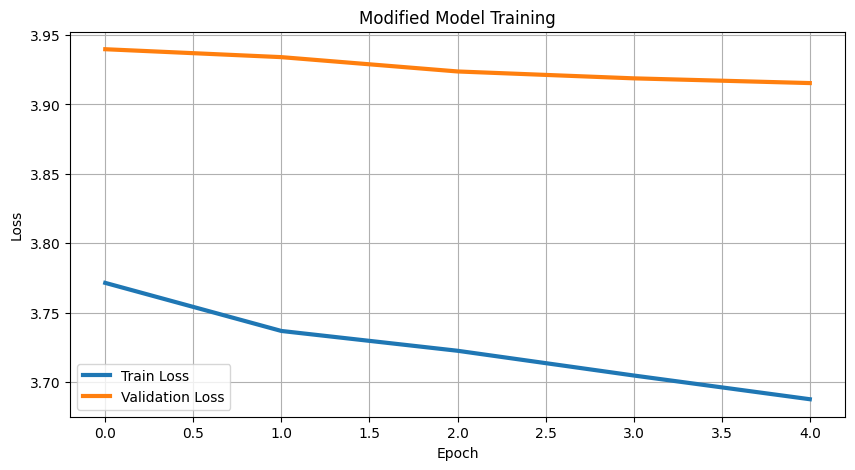


Training completed successfully.


In [63]:
# ============================================================
# MODIFIED MODEL — FINAL CLEAN EXECUTABLE VERSION
# GATED MULTIMODAL FUSION + MMM
# ============================================================

import os
import textwrap
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# SAVE DIRECTORY
# ============================================================

SAVE_DIR = "/content/gdrive/MyDrive/dnn project/epoch_outputs"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

print(f"Outputs will be saved to:\n{SAVE_DIR}")

# ============================================================
# GATED MULTIMODAL FUSION
# ============================================================

class GatedFusion(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.gate = nn.Sequential(

            nn.Linear(
                latent_dim * 2,
                latent_dim
            ),

            nn.Dropout(0.2),

            nn.Sigmoid()
        )

    def forward(
        self,
        z_text,
        z_image
    ):

        fusion_input = torch.cat(
            [z_text, z_image],
            dim=-1
        )

        gate = self.gate(
            fusion_input
        )

        fused = (
            gate * z_text
            +
            (1 - gate) * z_image
        )

        return fused


# ============================================================
# MODIFIED MODEL
# ============================================================

class ModifiedSequencePredictor(nn.Module):

    def __init__(
        self,
        visual_autoencoder,
        text_autoencoder,
        latent_dim
    ):

        super().__init__()

        self.image_encoder = visual_autoencoder.encoder

        self.text_encoder = text_autoencoder.encoder

        self.gated_fusion = GatedFusion(
            latent_dim
        )

        self.temporal_rnn = nn.GRU(
            latent_dim,
            latent_dim,
            batch_first=True,
            dropout=0.2
        )

        self.attention_layer = nn.Linear(
            latent_dim,
            1
        )

        self.projection = nn.Sequential(

            nn.Linear(
                latent_dim * 2,
                latent_dim
            ),

            nn.ReLU()
        )

        self.image_decoder = visual_autoencoder.decoder

        self.text_decoder = text_autoencoder.decoder

        self.fused_to_h0 = nn.Linear(
            latent_dim,
            latent_dim
        )

        self.fused_to_c0 = nn.Linear(
            latent_dim,
            latent_dim
        )

    # ========================================================
    # ATTENTION
    # ========================================================

    def attention(
        self,
        zseq
    ):

        energy = self.attention_layer(
            zseq
        ).squeeze(2)

        weights = torch.softmax(
            energy,
            dim=1
        )

        context = torch.bmm(
            weights.unsqueeze(1),
            zseq
        ).squeeze(1)

        return context

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        image_seq,
        text_seq,
        target_seq
    ):

        batch_size, seq_len, C, H, W = image_seq.shape

        # ====================================================
        # IMAGE FEATURES
        # ====================================================

        img_flat = image_seq.view(
            batch_size * seq_len,
            C,
            H,
            W
        )

        z_v_flat = self.image_encoder(
            img_flat
        )

        z_v_seq = z_v_flat.view(
            batch_size,
            seq_len,
            -1
        )

        # ====================================================
        # TEXT FEATURES
        # ====================================================

        txt_flat = text_seq.view(
            batch_size * seq_len,
            -1
        )

        _, hidden, _ = self.text_encoder(
            txt_flat
        )

        z_t_flat = hidden.squeeze(0)

        z_t_seq = z_t_flat.view(
            batch_size,
            seq_len,
            -1
        )

        # ====================================================
        # GATED FUSION
        # ====================================================

        z_fused = self.gated_fusion(
            z_t_seq,
            z_v_seq
        )

        # ====================================================
        # TEMPORAL MODEL
        # ====================================================

        zseq, h = self.temporal_rnn(
            z_fused
        )

        h = h.squeeze(0)

        # ====================================================
        # ATTENTION
        # ====================================================

        context = self.attention(
            zseq
        )

        # ====================================================
        # FINAL LATENT
        # ====================================================

        z = self.projection(
            torch.cat(
                [h, context],
                dim=1
            )
        )

        # ====================================================
        # IMAGE OUTPUT
        # ====================================================

        pred_img_content, pred_img_context = self.image_decoder(
            z
        )

        # ====================================================
        # TEXT OUTPUT
        # ====================================================

        h0 = self.fused_to_h0(
            z
        ).unsqueeze(0)

        c0 = self.fused_to_c0(
            z
        ).unsqueeze(0)

        decoder_input = target_seq[:, :, :-1].squeeze(1)

        pred_txt, _, _ = self.text_decoder(
            decoder_input,
            h0,
            c0
        )

        return (
            pred_img_content,
            pred_img_context,
            pred_txt
        )


# ============================================================
# MMM MASKING
# ============================================================

MASK_PROB = 0.15

def apply_mmm_mask(text_tensor):

    masked = text_tensor.clone()

    rand = torch.rand(
        masked.shape,
        device=masked.device
    )

    mask = rand < MASK_PROB

    masked[mask] = tokenizer.mask_token_id

    return masked


# ============================================================
# INITIALIZE MODEL
# ============================================================

latent_dim = 16

modified_model = ModifiedSequencePredictor(
    visual_autoencoder,
    text_autoencoder,
    latent_dim
).to(device)

optimizer_mod = torch.optim.Adam(
    modified_model.parameters(),
    lr=0.001
)

criterion_images = nn.SmoothL1Loss()

criterion_ctx = nn.MSELoss()

criterion_text = nn.CrossEntropyLoss(
    ignore_index=tokenizer.convert_tokens_to_ids(
        tokenizer.pad_token
    )
)

print("Modified model initialized successfully.")

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_modified_epoch(
    model,
    optimizer
):

    model.train()

    total_loss = 0

    for batch in train_dataloader:

        (
            frames,
            descriptions,
            image_target,
            text_target,
            *_
        ) = batch

        frames = frames.to(device)

        descriptions = descriptions.to(device)

        image_target = image_target.to(device)

        text_target = text_target.to(device)

        masked_descriptions = apply_mmm_mask(
            descriptions
        )

        optimizer.zero_grad()

        pred_img, pred_ctx, pred_txt = model(
            frames,
            masked_descriptions,
            text_target
        )

        # ====================================================
        # IMAGE LOSS
        # ====================================================

        loss_img = criterion_images(
            pred_img,
            image_target
        )

        # ====================================================
        # CONTEXT LOSS
        # ====================================================

        mu_global = frames.mean(
            dim=[0,1]
        )

        mu_global = mu_global.unsqueeze(0).expand_as(
            pred_ctx
        )

        loss_context = criterion_ctx(
            pred_ctx,
            mu_global
        )

        # ====================================================
        # TEXT LOSS
        # ====================================================

        loss_txt = criterion_text(

            pred_txt.reshape(
                -1,
                tokenizer.vocab_size
            ),

            text_target.squeeze(1)[:,1:].reshape(-1)
        )

        # ====================================================
        # TOTAL LOSS
        # ====================================================

        loss = (
            loss_img
            +
            loss_txt
            +
            0.1 * loss_context
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_dataloader)


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_modified(model):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in val_dataloader:

            (
                frames,
                descriptions,
                image_target,
                text_target,
                *_
            ) = batch

            frames = frames.to(device)

            descriptions = descriptions.to(device)

            image_target = image_target.to(device)

            text_target = text_target.to(device)

            pred_img, pred_ctx, pred_txt = model(
                frames,
                descriptions,
                text_target
            )

            loss_img = criterion_images(
                pred_img,
                image_target
            )

            mu_global = frames.mean(
                dim=[0,1]
            )

            mu_global = mu_global.unsqueeze(0).expand_as(
                pred_ctx
            )

            loss_context = criterion_ctx(
                pred_ctx,
                mu_global
            )

            loss_txt = criterion_text(

                pred_txt.reshape(
                    -1,
                    tokenizer.vocab_size
                ),

                text_target.squeeze(1)[:,1:].reshape(-1)
            )

            loss = (
                loss_img
                +
                loss_txt
                +
                0.1 * loss_context
            )

            total_loss += loss.item()

    return total_loss / len(val_dataloader)


# ============================================================
# IMAGE DISPLAY
# ============================================================

def show_image(ax, img_tensor):

    img = img_tensor.detach().cpu().permute(1,2,0).numpy()

    img = (
        img - img.min()
    ) / (
        img.max() - img.min() + 1e-8
    )

    ax.imshow(img)

    ax.axis("off")


# ============================================================
# SAVE EPOCH RESULTS
# ============================================================

def save_epoch_results(
    epoch,
    baseline_model,
    modified_model
):

    baseline_model.eval()

    modified_model.eval()

    batch = next(iter(val_dataloader))

    (
        frames,
        descriptions,
        image_target,
        text_target,
        *_
    ) = batch

    frames = frames.to(device)

    descriptions = descriptions.to(device)

    image_target = image_target.to(device)

    text_target = text_target.to(device)

    # ========================================================
    # BASELINE
    # ========================================================

    with torch.no_grad():

        baseline_outputs = baseline_model(
            frames,
            descriptions,
            text_target
        )

    baseline_img = baseline_outputs[0]

    # ========================================================
    # MODIFIED
    # ========================================================

    with torch.no_grad():

        modified_outputs = modified_model(
            frames,
            descriptions,
            text_target
        )

    modified_img = modified_outputs[0]

    # ========================================================
    # GROUND TRUTH TEXT
    # ========================================================

    ground_truth = tokenizer.decode(
        text_target[0][0],
        skip_special_tokens=True
    )

    # ========================================================
    # CREATE FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        2,
        7,
        figsize=(30,10),
        gridspec_kw={
            'height_ratios':[1,1.5]
        }
    )

    # ========================================================
    # INPUTS
    # ========================================================

    for i in range(4):

        show_image(
            ax[0,i],
            frames[0,i]
        )

        ax[0,i].set_title(
            f"Input {i+1}"
        )

        txt = tokenizer.decode(
            descriptions[0,i],
            skip_special_tokens=True
        )

        txt = textwrap.fill(
            txt,
            width=40
        )

        ax[1,i].text(
            0.01,
            0.99,
            txt,
            fontsize=9,
            va='top'
        )

        ax[1,i].axis("off")

    # ========================================================
    # GROUND TRUTH
    # ========================================================

    show_image(
        ax[0,4],
        image_target[0]
    )

    ax[0,4].set_title(
        "Ground Truth"
    )

    gt = textwrap.fill(
        ground_truth,
        width=40
    )

    ax[1,4].text(
        0.01,
        0.99,
        gt,
        fontsize=9,
        va='top'
    )

    ax[1,4].axis("off")

    # ========================================================
    # BASELINE IMAGE
    # ========================================================

    show_image(
        ax[0,5],
        baseline_img[0]
    )

    ax[0,5].set_title(
        "Baseline"
    )

    ax[1,5].text(
        0.01,
        0.99,
        "Baseline Generated Output",
        fontsize=9,
        va='top'
    )

    ax[1,5].axis("off")

    # ========================================================
    # MODIFIED IMAGE
    # ========================================================

    show_image(
        ax[0,6],
        modified_img[0]
    )

    ax[0,6].set_title(
        "Modified"
    )

    ax[1,6].text(
        0.01,
        0.99,
        "Modified Generated Output",
        fontsize=9,
        va='top'
    )

    ax[1,6].axis("off")

    # ========================================================
    # SAVE IMAGE
    # ========================================================

    image_path = os.path.join(
        SAVE_DIR,
        f"epoch_{epoch+1}_results.png"
    )

    plt.tight_layout()

    plt.savefig(
        image_path,
        bbox_inches='tight'
    )

    plt.close()

    print(f"Saved:\n{image_path}")


# ============================================================
# TRAINING LOOP
# ============================================================

EPOCHS = 5

train_losses_mod = []

val_losses_mod = []

for epoch in range(EPOCHS):

    train_loss = train_modified_epoch(
        modified_model,
        optimizer_mod
    )

    val_loss = validate_modified(
        modified_model
    )

    train_losses_mod.append(
        train_loss
    )

    val_losses_mod.append(
        val_loss
    )

    print(f"""
==================================================
Epoch {epoch+1}/{EPOCHS}

Train Loss      : {train_loss:.4f}

Validation Loss : {val_loss:.4f}
==================================================
""")

    # ========================================================
    # SAVE EPOCH OUTPUTS
    # ========================================================

    save_epoch_results(
        epoch,
        sequence_predictor,
        modified_model
    )


# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    train_losses_mod,
    linewidth=3,
    label="Train Loss"
)

plt.plot(
    val_losses_mod,
    linewidth=3,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Modified Model Training"
)

plt.legend()

plt.grid(True)

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "loss_curve.png"
    )
)

plt.show()

print("\nTraining completed successfully.")

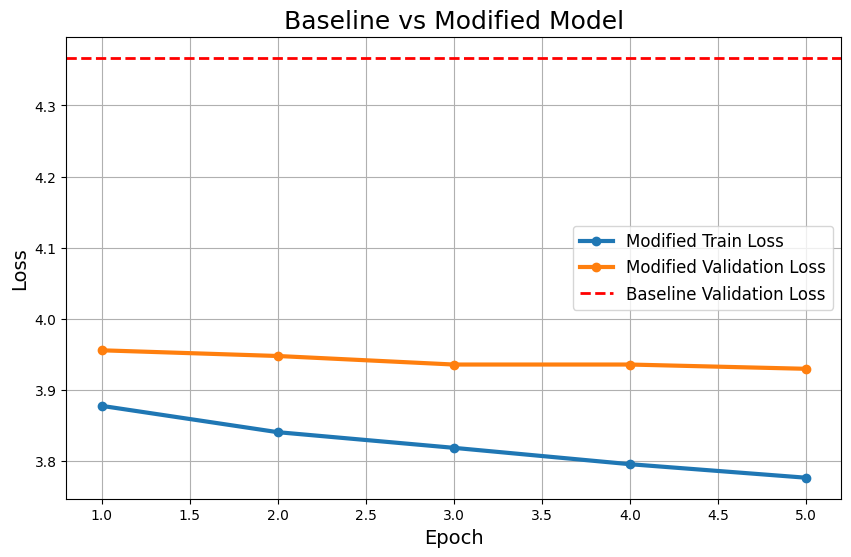


GRAPH SAVED SUCCESSFULLY

Saved at:

/content/gdrive/MyDrive/Dnn project/loss_comparison.png



In [64]:
# ============================================================
# BASELINE vs MODIFIED LOSS COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# BASELINE LOSS
# (replace with your actual baseline validation loss)
# ------------------------------------------------------------

baseline_validation_loss = 4.367

# ------------------------------------------------------------
# MODIFIED MODEL LOSSES
# ------------------------------------------------------------

modified_train_losses = [
    3.878,
    3.841,
    3.819,
    3.796,
    3.777
]

modified_validation_losses = [
    3.956,
    3.948,
    3.936,
    3.936,
    3.930
]

epochs = range(1, 6)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,6))

# ------------------------------------------------------------
# MODIFIED TRAIN
# ------------------------------------------------------------

plt.plot(
    epochs,
    modified_train_losses,
    marker='o',
    linewidth=3,
    label='Modified Train Loss'
)

# ------------------------------------------------------------
# MODIFIED VALIDATION
# ------------------------------------------------------------

plt.plot(
    epochs,
    modified_validation_losses,
    marker='o',
    linewidth=3,
    label='Modified Validation Loss'
)

# ------------------------------------------------------------
# BASELINE VALIDATION
# ------------------------------------------------------------

plt.axhline(
    y=baseline_validation_loss,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Baseline Validation Loss'
)

# ============================================================
# LABELS
# ============================================================

plt.title(
    'Baseline vs Modified Model',
    fontsize=18
)

plt.xlabel(
    'Epoch',
    fontsize=14
)

plt.ylabel(
    'Loss',
    fontsize=14
)

plt.legend(
    fontsize=12
)

plt.grid(True)

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    '/content/gdrive/MyDrive/dnn project/loss_comparison.png',
    bbox_inches='tight'
)

plt.show()

print("""
==================================================
GRAPH SAVED SUCCESSFULLY
==================================================

Saved at:

/content/gdrive/MyDrive/Dnn project/loss_comparison.png
==================================================
""")


BLEU SCORE RESULTS

Baseline BLEU : 0.0335
Modified BLEU : 0.0339


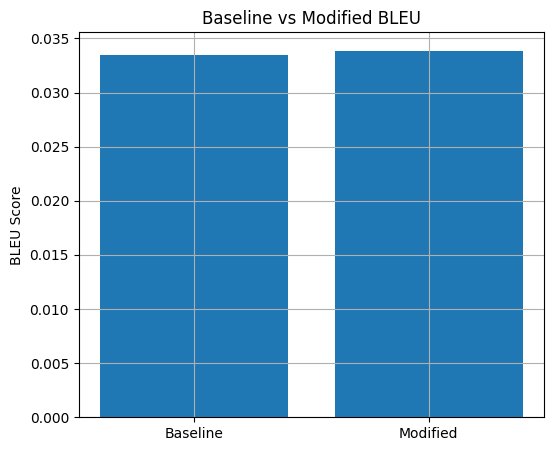


BLEU GRAPH SAVED

Saved at:

/content/gdrive/MyDrive/dnn project/epoch_outputs/bleu_comparison.png



In [65]:
# ============================================================
# BLEU SCORE EVALUATION
# BASELINE vs MODIFIED
# ============================================================

from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

smoothie = SmoothingFunction().method4

# ============================================================
# GENERATE TEXT FUNCTION
# ============================================================

def generate_text(model, frames, descriptions, text_target):

    model.eval()

    with torch.no_grad():

        outputs = model(
            frames,
            descriptions,
            text_target
        )

    pred_txt = outputs[2]

    predicted_ids = torch.argmax(
        pred_txt,
        dim=-1
    )[0]

    generated_text = tokenizer.decode(
        predicted_ids,
        skip_special_tokens=True
    )

    return generated_text


# ============================================================
# BLEU EVALUATION
# ============================================================

def evaluate_bleu(
    baseline_model,
    modified_model,
    num_samples=20
):

    baseline_scores = []

    modified_scores = []

    for i, batch in enumerate(val_dataloader):

        if i >= num_samples:
            break

        (
            frames,
            descriptions,
            image_target,
            text_target,
            *_
        ) = batch

        frames = frames.to(device)

        descriptions = descriptions.to(device)

        text_target = text_target.to(device)

        # ====================================================
        # GROUND TRUTH
        # ====================================================

        reference = tokenizer.decode(
            text_target[0][0],
            skip_special_tokens=True
        )

        reference_tokens = reference.split()

        # ====================================================
        # BASELINE
        # ====================================================

        baseline_text = generate_text(
            sequence_predictor,
            frames,
            descriptions,
            text_target
        )

        baseline_bleu = sentence_bleu(
            [reference_tokens],
            baseline_text.split(),
            smoothing_function=smoothie
        )

        baseline_scores.append(
            baseline_bleu
        )

        # ====================================================
        # MODIFIED
        # ====================================================

        modified_text = generate_text(
            modified_model,
            frames,
            descriptions,
            text_target
        )

        modified_bleu = sentence_bleu(
            [reference_tokens],
            modified_text.split(),
            smoothing_function=smoothie
        )

        modified_scores.append(
            modified_bleu
        )

    baseline_avg = np.mean(
        baseline_scores
    )

    modified_avg = np.mean(
        modified_scores
    )

    return baseline_avg, modified_avg


# ============================================================
# RUN BLEU EVALUATION
# ============================================================

baseline_bleu, modified_bleu = evaluate_bleu(
    sequence_predictor,
    modified_model
)

print("""
==================================================
BLEU SCORE RESULTS
==================================================
""")

print(f"Baseline BLEU : {baseline_bleu:.4f}")

print(f"Modified BLEU : {modified_bleu:.4f}")

# ============================================================
# PLOT BLEU COMPARISON
# ============================================================

plt.figure(figsize=(6,5))

models = [
    "Baseline",
    "Modified"
]

scores = [
    baseline_bleu,
    modified_bleu
]

plt.bar(
    models,
    scores
)

plt.ylabel("BLEU Score")

plt.title(
    "Baseline vs Modified BLEU"
)

plt.grid(True)

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "/content/gdrive/MyDrive/dnn project/epoch_outputs/bleu_comparison.png",
    bbox_inches='tight'
)

plt.show()

print("""
==================================================
BLEU GRAPH SAVED
==================================================

Saved at:

/content/gdrive/MyDrive/dnn project/epoch_outputs/bleu_comparison.png
==================================================
""")